<a href="https://colab.research.google.com/github/astridmeilendra/WondrByBNI-SentimenAnalysis/blob/main/Week%202%20%26%20Week%203%20/%20Week_3_WondrbyBNI_Review_Exploratory_Data_Analysis_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#WEEK 3 WondrByBNI Gooogle Apss Review - Exploratory Data Analysis (EDA)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/PBA/Dataset Tugas 1/df_wondrRev.csv')
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,1690dc88-5f2c-41a1-b074-aa9b06286280,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus dan sangat membantu,5,0,1.5.0,2026-04-03 22:22:29,NaN,NaN,1.5.0
1,4b7df975-23ed-46a6-84da-14e7feb16791,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baik,5,0,1.5.0,2026-04-03 21:56:59,NaN,NaN,1.5.0
2,8cd7726f-c584-4c68-9152-4a4959367957,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mudah dan simpel,5,0,1.5.0,2026-04-03 21:50:38,NaN,NaN,1.5.0
3,57a144a9-f2f6-4188-9630-4cb11a427148,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,4,0,1.5.0,2026-04-03 20:28:02,"Hai Kak Soni Setyawan, terima kasih ya buat re...",2026-04-04 06:50:17,1.5.0
4,1a06a3dc-9e5f-44a1-b222-aaccc0433103,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"lebih mudah, dan praktis",5,0,1.5.0,2026-04-03 19:30:59,NaN,NaN,1.5.0
...,...,...,...,...,...,...,...,...,...,...,...
89449,87a5a553-753b-43ac-8838-601e3bd980b4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Simpel..mantab,5,2,1.0.1,2024-07-01 02:47:55,NaN,NaN,1.0.1
89450,e95d3b71-c5cc-4647-b808-3abb9a9a2621,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Makin simple dan lengkap. Terkoneksi dengan al...,5,22,1.0.1,2024-07-01 02:45:01,NaN,NaN,1.0.1
89451,f77a4113-913b-49d9-878d-ab6e2bf1625b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tampilannya keren👏👏,5,3,1.0.1,2024-07-01 02:43:33,NaN,NaN,1.0.1
89452,b9d34289-c81f-477e-98f7-1a6287f01357,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Canggih...,5,2,1.0.1,2024-07-01 02:33:41,NaN,NaN,1.0.1


# Exploratory Data Analysis (EDA) of JKN Reviews

## 1. Install Necessary Packages
This section ensures that all required Python packages are installed before running the notebook.
```python
!pip install pandas matplotlib seaborn nltk
```

In [3]:
!pip install pandas matplotlib seaborn nltk

## 2. Import Required Libraries
We import essential libraries for data analysis, visualization, and text processing.
```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
```

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 3. Data Overview
This section provides basic dataset information, including column names, data types, and the first few records.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89454 entries, 0 to 89453
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              89454 non-null  object
 1   userName              89454 non-null  object
 2   userImage             89454 non-null  object
 3   content               89454 non-null  object
 4   score                 89454 non-null  int64 
 5   thumbsUpCount         89454 non-null  int64 
 6   reviewCreatedVersion  80715 non-null  object
 7   at                    89454 non-null  object
 8   replyContent          36101 non-null  object
 9   repliedAt             36101 non-null  object
 10  appVersion            80715 non-null  object
dtypes: int64(2), object(9)
memory usage: 7.5+ MB


In [6]:
df.head(5)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,1690dc88-5f2c-41a1-b074-aa9b06286280,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus dan sangat membantu,5,0,1.5.0,2026-04-03 22:22:29,NaN,NaN,1.5.0
1,4b7df975-23ed-46a6-84da-14e7feb16791,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baik,5,0,1.5.0,2026-04-03 21:56:59,NaN,NaN,1.5.0
2,8cd7726f-c584-4c68-9152-4a4959367957,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mudah dan simpel,5,0,1.5.0,2026-04-03 21:50:38,NaN,NaN,1.5.0
3,57a144a9-f2f6-4188-9630-4cb11a427148,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus,4,0,1.5.0,2026-04-03 20:28:02,"Hai Kak Soni Setyawan, terima kasih ya buat re...",2026-04-04 06:50:17,1.5.0
4,1a06a3dc-9e5f-44a1-b222-aaccc0433103,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"lebih mudah, dan praktis",5,0,1.5.0,2026-04-03 19:30:59,NaN,NaN,1.5.0


## 4. Missing Values Analysis
Identifies and counts missing values in each column.


In [7]:
missing = df.isnull().sum()
missing

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,8739
at,0
replyContent,53353
repliedAt,53353


## 5. Duplicate Reviews Check

This step checks for duplicate values in the reviewId and content columns. It counts how many duplicates exist and displays them. If duplicate review texts are found, the top five most frequent ones are shown to help identify data redundancy.

In [8]:
# Duplicate reviews check
dup_reviewid = df['reviewId'].duplicated().sum()
dup_content = df['content'].duplicated().sum()

print(f'Duplicate reviewIds   : {dup_reviewid:,}')
print(f'Duplicate content text: {dup_content:,}')

# Show examples of duplicated content (if any)
if dup_content > 0:
    print(f'\nTop 5 most repeated review texts:')
    print(df['content'].value_counts().head())

Duplicate reviewIds   : 0
Duplicate content text: 34,480

Top 5 most repeated review texts:
content
mantap    3770
bagus     3008
ok        2297
baik      1835
good      1663
Name: count, dtype: int64


## 6. Score Distribution Analysis

This step analyzes the distribution of review scores in the dataset. It helps to understand how ratings are spread (e.g., positive, neutral, or negative) and provides insights into overall user satisfaction.

In [9]:
count = df['score'].value_counts().sort_index()
df_count = pd.DataFrame(count).reset_index()
df_count.columns = ['score', 'count']
df_count = df_count[['score', 'count']]
df_count

,score,count
0,1,15961
1,2,3854
2,3,4308
3,4,5576
4,5,59755


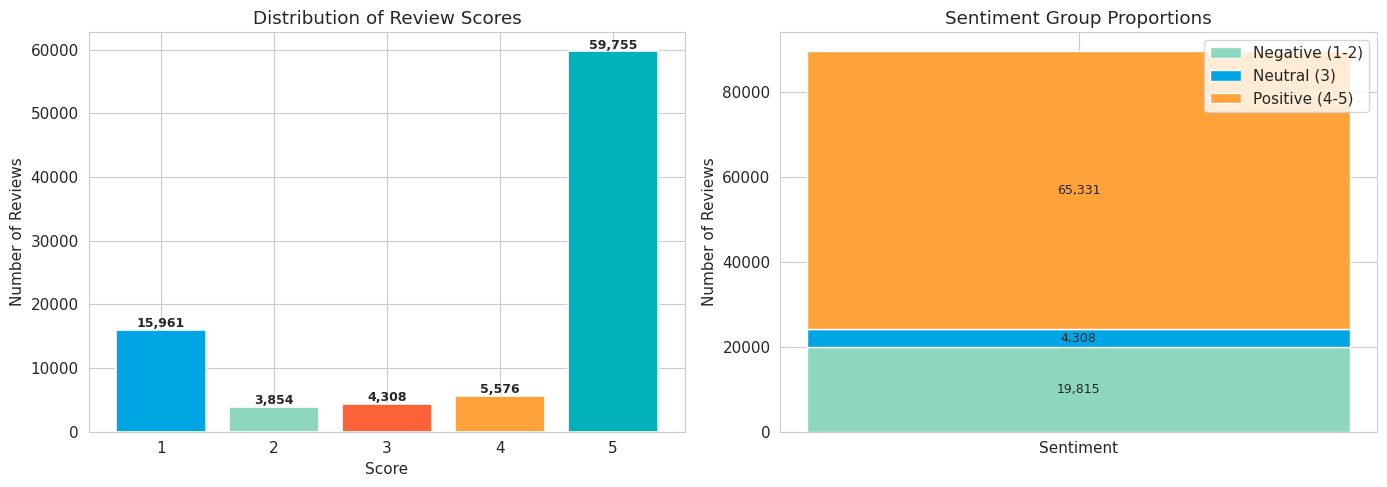


Sentiment grouping: Negative = 19,815  Neutral = 4,308  Positive = 65,331


In [13]:
import matplotlib.pyplot as plt

# Score distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------
# Bar chart (kiri)
# ------------------------
colors = ['#00A5E3', '#8DD7BF', '#FC6238', '#FFA23A', '#00B0BA']

axes[0].bar(df_count['score'], df_count['count'],
            color=colors, edgecolor='white', linewidth=1.2)

axes[0].set_xlabel('Score')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_title('Distribution of Review Scores')
axes[0].set_xticks(range(1, 6))

# Label angka di atas bar
for _, row in df_count.iterrows():
    axes[0].text(row['score'],
                 row['count'] + len(df) * 0.005,
                 f"{row['count']:,}",
                 ha='center',
                 fontsize=9,
                 fontweight='bold')

# ------------------------
# Stacked Bar (kanan)
# ------------------------
negative = df_count[df_count['score'].isin([1, 2])]['count'].sum()
neutral  = df_count[df_count['score'] == 3]['count'].sum()
positive = df_count[df_count['score'].isin([4, 5])]['count'].sum()

# Warna sesuai tone
neg_color = '#8DD7BF'   # biru muda
neu_color = '#00A5E3'   # biru tua
pos_color = '#FFA23A'   # kuning

axes[1].bar('Sentiment', negative, color=neg_color, label='Negative (1-2)')
axes[1].bar('Sentiment', neutral, bottom=negative, color=neu_color, label='Neutral (3)')
axes[1].bar('Sentiment', positive, bottom=negative + neutral, color=pos_color, label='Positive (4-5)')

axes[1].set_ylabel('Number of Reviews')
axes[1].set_title('Sentiment Group Proportions')
axes[1].legend()

# Tambahin angka di tiap segmen
axes[1].text(0, negative / 2, f'{negative:,}', ha='center', va='center', fontsize=9)
axes[1].text(0, negative + neutral / 2, f'{neutral:,}', ha='center', va='center', fontsize=9)
axes[1].text(0, negative + neutral + positive / 2, f'{positive:,}', ha='center', va='center', fontsize=9)

# ------------------------
# Show
# ------------------------
plt.tight_layout()
plt.show()

print(f'\nSentiment grouping: Negative = {negative:,}  Neutral = {neutral:,}  Positive = {positive:,}')

## 7. Temporal Analysis

This step analyzes how reviews change over time based on the date. It helps identify trends, patterns, or shifts in user feedback across different periods.

In [14]:
df['at'] = pd.to_datetime(df['at'])
df['year'] = df['at'].dt.year
df['month'] = df['at'].dt.to_period('M')

print(f'Review date range: {df["at"].min().date()} to {df["at"].max().date()}')
print(f'Total span: {(df["at"].max() - df["at"].min()).days:,} days')

Review date range: 2024-07-01 to 2026-04-03
Total span: 641 days


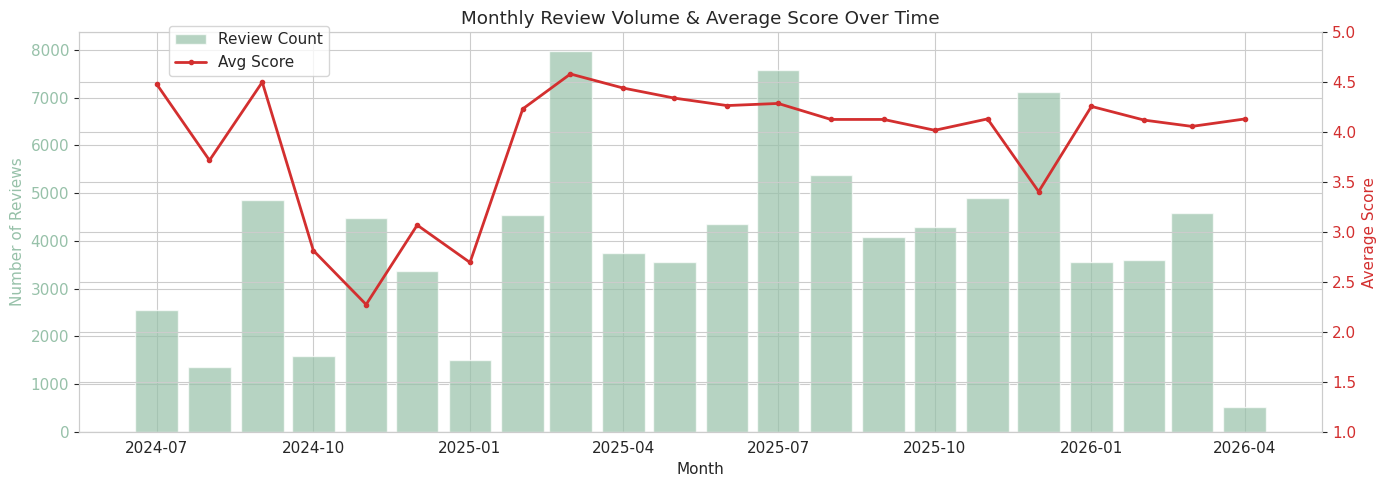

In [15]:
monthly = df.groupby('month').agg(
    review_count=('content', 'count'),
    avg_score=('score', 'mean')
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Review count (bars)
ax1.bar(monthly['month_dt'], monthly['review_count'], width=25,
        color='#97c1a9', alpha=0.7, label='Review Count')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Reviews', color='#97c1a9')
ax1.tick_params(axis='y', labelcolor='#97c1a9')

# Average score (line overlay)
ax2 = ax1.twinx()
ax2.plot(monthly['month_dt'], monthly['avg_score'], color='#d32f2f',
         linewidth=2, marker='o', markersize=3, label='Avg Score')
ax2.set_ylabel('Average Score', color='#d32f2f')
ax2.set_ylim(1, 5)
ax2.tick_params(axis='y', labelcolor='#d32f2f')

plt.title('Monthly Review Volume & Average Score Over Time')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()

In [16]:
yearly = df.groupby('year').agg(
    review_count=('content', 'count'),
    avg_score=('score', 'mean')
).round(2)

print('Yearly Summary:')
yearly

Yearly Summary:


,review_count,avg_score
year,,
2024,18217,3.48
2025,58984,4.13
2026,12253,4.14


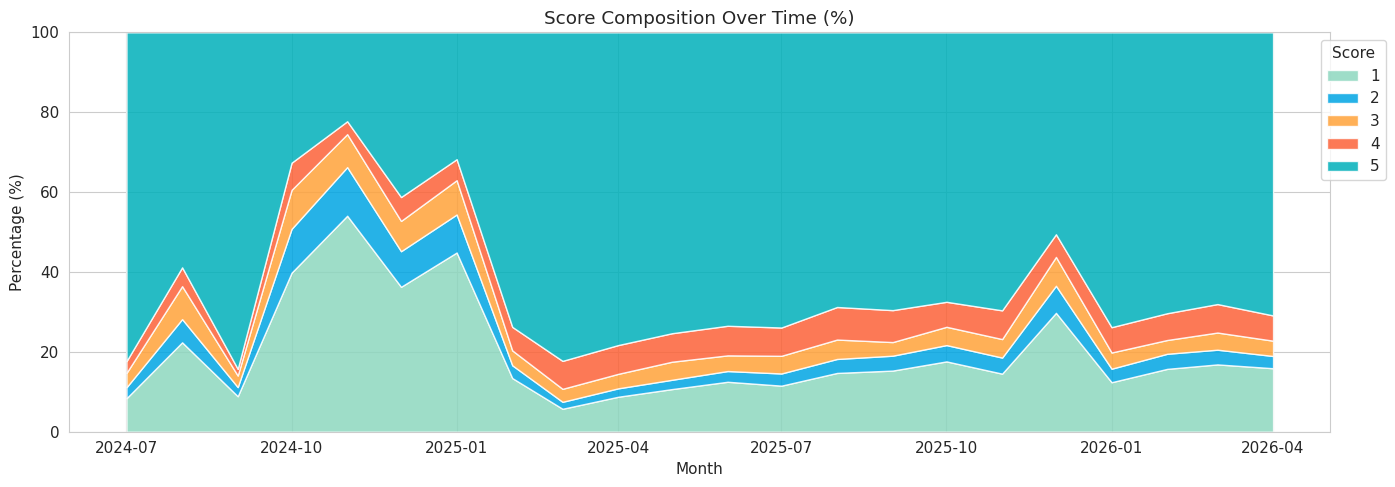

In [24]:
import matplotlib.pyplot as plt

# Hitung data bulanan
monthly_scores = df.groupby(['month', 'score']).size().unstack(fill_value=0)
monthly_scores.index = monthly_scores.index.to_timestamp()

# Persentase
monthly_pct = monthly_scores.div(monthly_scores.sum(axis=1), axis=0) * 100

# Warna (biar konsisten & lebih enak dilihat)
colors = ['#8DD7BF', '#00A5E3', '#FFA23A', '#FC6238', '#00B0BA']

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.stackplot(
    monthly_pct.index,
    monthly_pct.T,   # transpose biar sesuai format stackplot
    colors=colors,
    alpha=0.85
)

# Styling
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Month')
ax.set_title('Score Composition Over Time (%)')
ax.set_ylim(0, 100)

# Legend manual (biar jelas)
ax.legend(['1', '2', '3', '4', '5'], title='Score', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [25]:
df['review_length'] = df['content'].astype(str).str.len()
df['word_count'] = df['content'].astype(str).str.split().str.len()

print('Review Length (characters):')
print(df['review_length'].describe().round(1))
print(f'\nReview Word Count:')
print(df['word_count'].describe().round(1))

Review Length (characters):
count    89454.0
mean        49.3
std         69.5
min          1.0
25%          7.0
50%         22.0
75%         61.0
max        500.0
Name: review_length, dtype: float64

Review Word Count:
count    89454.0
mean         7.9
std         11.1
min          1.0
25%          1.0
50%          3.0
75%         10.0
max         94.0
Name: word_count, dtype: float64


##8. Review Length Analysis

This step analyzes the length of reviews based on their scores. It uses a box plot and histogram to show how review length varies across different rating levels. Additionally, the average word count per score is calculated to identify patterns in user feedback.

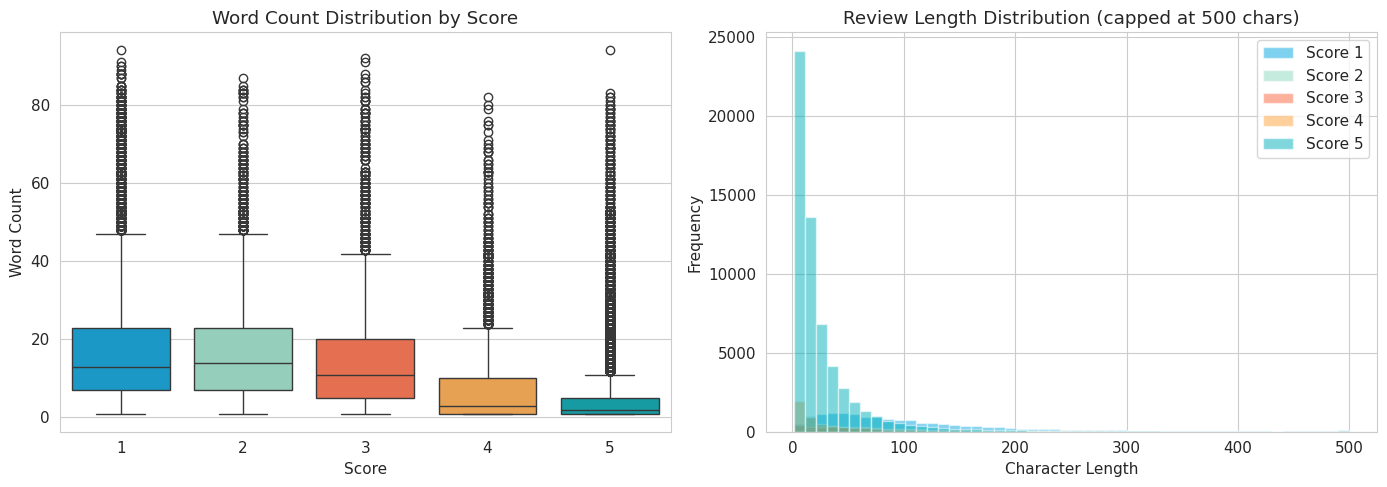


Average word count by score:
score
1    17.4
2    17.5
3    15.0
4     7.5
5     4.3
Name: word_count, dtype: float64


In [30]:
# Review length distribution by score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of word count per score
df.boxplot(
    column='word_count',
    by='score',
    ax=axes[0],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor='#00A5E3', alpha=0.7)
)

axes[0].set_title('Word Count Distribution by Score')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Word Count')
axes[0].get_figure().suptitle('')  # remove automatic title

# Histogram of review lengths (capped at 500 characters)
for s in range(1, 6):
    subset = df[df['score'] == s]['review_length']
    axes[1].hist(
        subset.clip(upper=500),
        bins=50,
        alpha=0.5,
        label=f'Score {s}',
        color=colors[s-1]
    )

axes[1].set_title('Review Length Distribution (capped at 500 chars)')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nAverage word count by score:')
print(df.groupby('score')['word_count'].mean().round(1))

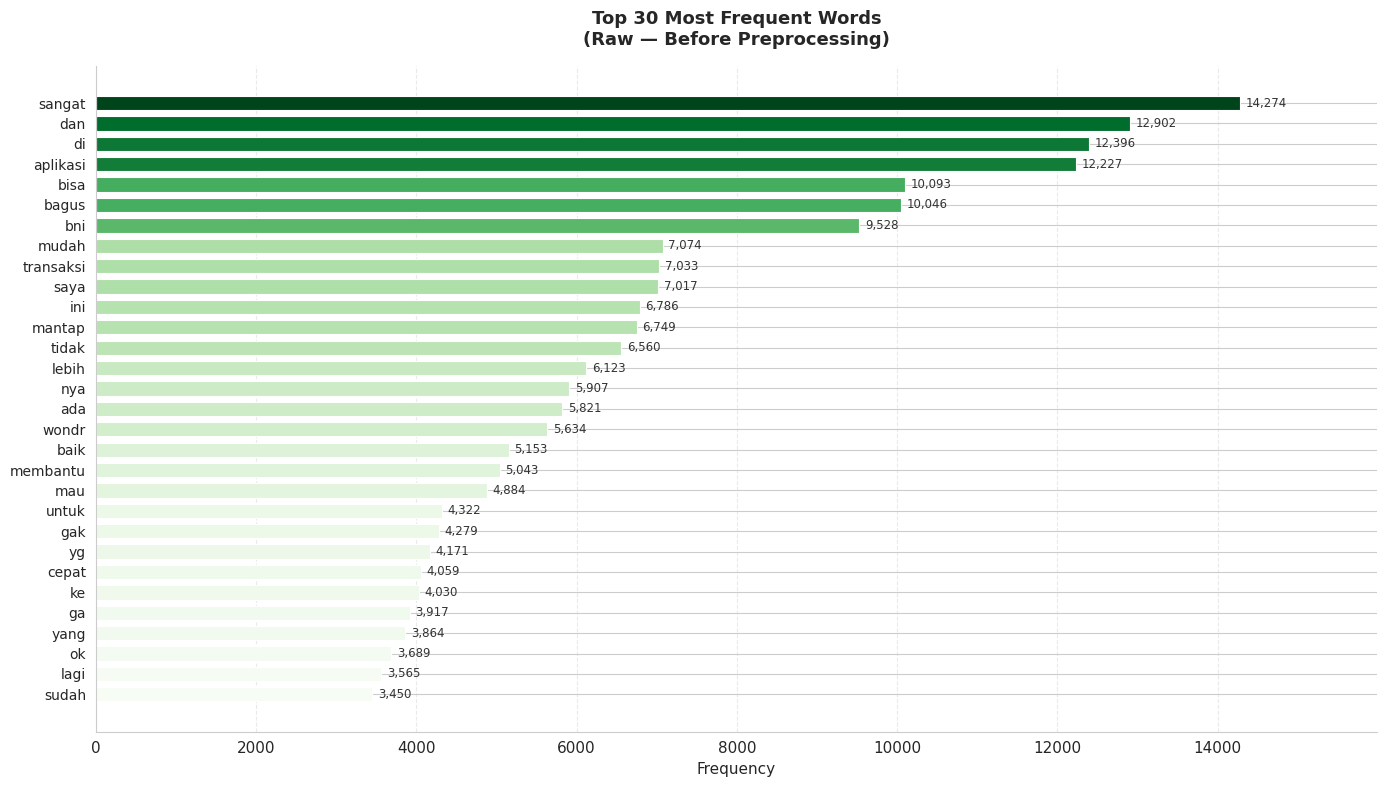

In [31]:
# Most common words (raw, before preprocessing)
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

all_words = ' '.join(df['content'].astype(str).str.lower()).split()
word_freq = Counter(all_words)

top_30 = word_freq.most_common(30)
words, counts = zip(*top_30)

# Gradient color based on frequency (Green gradient)
norm = plt.Normalize(min(counts), max(counts))
colors = cm.Greens(norm(counts))

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(words)), counts, color=colors, edgecolor='white', linewidth=0.8, height=0.7)

# Add count labels
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(bar.get_width() + max(counts) * 0.005, i, f'{count:,}',
            va='center', fontsize=8.5, color='#333333')

ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Frequency', fontsize=11)
ax.set_title('Top 30 Most Frequent Words\n(Raw — Before Preprocessing)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, max(counts) * 1.12)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

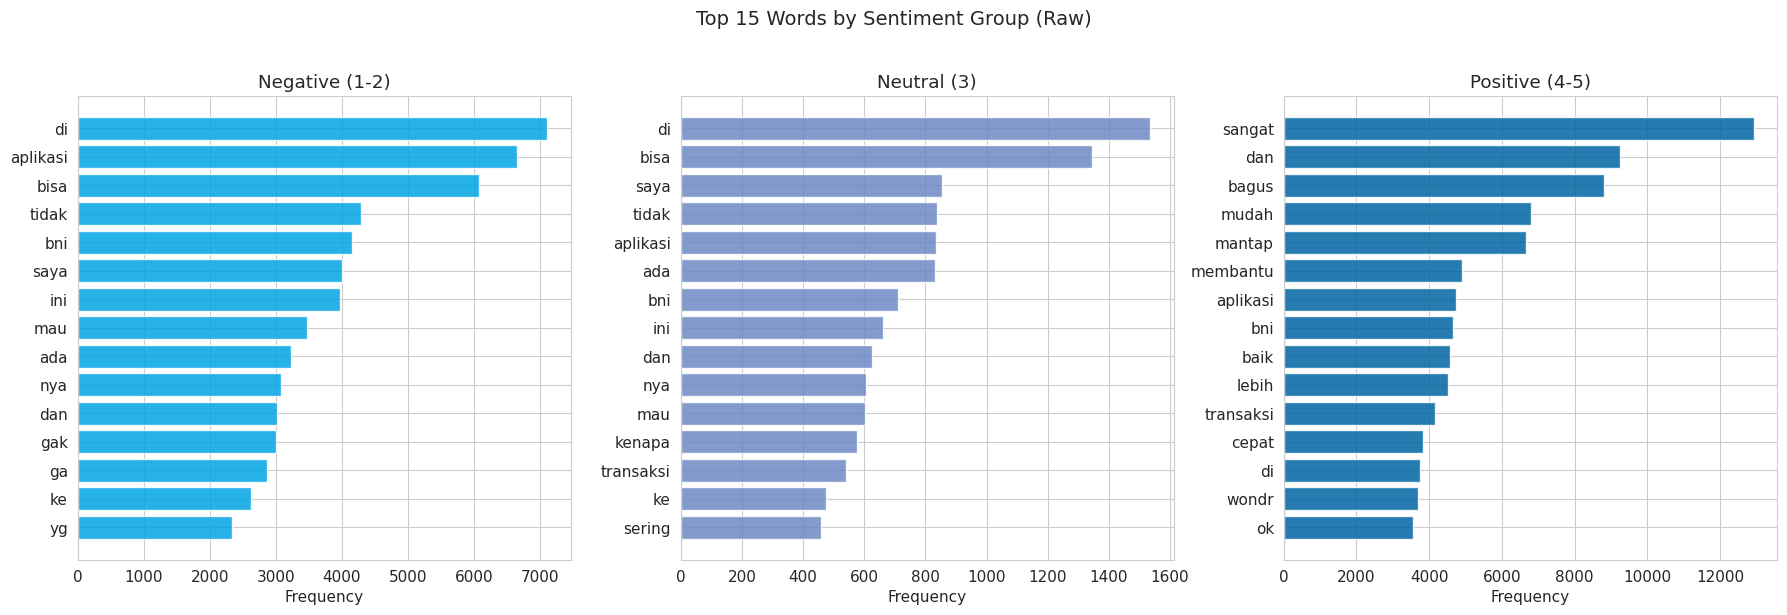

In [32]:
# Most common words split by sentiment group
def get_top_words(subset_df, n=15):
    text = ' '.join(subset_df['content'].astype(str).str.lower())
    return Counter(text.split()).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
groups = {
    'Negative (1-2)': df[df['score'].isin([1, 2])],
    'Neutral (3)': df[df['score'] == 3],
    'Positive (4-5)': df[df['score'].isin([4, 5])]
}

# Custom colors (sesuai request)
group_colors = ['#00A5E3', '#6C88C4', '#0065A2']

for ax, (label, group_df), color in zip(axes, groups.items(), group_colors):
    top_w = get_top_words(group_df)
    w, c = zip(*top_w)
    ax.barh(range(len(w)), c, color=color, alpha=0.85)
    ax.set_yticks(range(len(w)))
    ax.set_yticklabels(w)
    ax.invert_yaxis()
    ax.set_title(label)
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Words by Sentiment Group (Raw)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
# Examples of very short and very long reviews
print('=== SHORTEST REVIEWS (1-2 words) ===')
short = df[df['word_count'] <= 2][['content', 'score']].sample(min(10, len(df[df['word_count'] <= 2])), random_state=42)
for _, row in short.iterrows():
    print(f'  [{row["score"]}] {row["content"]}')

print(f'\n=== LONGEST REVIEWS (top 5 by word count) ===')
long = df.nlargest(5, 'word_count')[['content', 'score', 'word_count']]
for _, row in long.iterrows():
    print(f'  [{row["score"]}] ({row["word_count"]} words) {row["content"][:150]}...')


=== SHORTEST REVIEWS (1-2 words) ===
  [1] SUKA BERMASALAH
  [2] ok
  [5] mantap
  [5] terbaik
  [4] keren
  [5] Mantap🇮🇩🇮🇩🇮🇩
  [5] aplikasinya bagus
  [1] lola, ribet
  [5] mantap
  [5] bagus

=== LONGEST REVIEWS (top 5 by word count) ===
  [5] (94 words) maaf nih BNI kok bisa ya kan saya udah masuk nih udah diterima lah misalnya ini saya mau masuk lagi lihat lagi disuruh masukan pasword nah pasword uda...
  [1] (94 words) aplikasi wondr payah hp ke reset sama anak pas mau masuk lagi suruh isi data KTP sama kartu ATM udah di isi semua pas terakhir foto Selfi kaga bisa bi...
  [3] (92 words) maaf min aplksi wonder knpa ya pas awal² daftar masih bisa tf tp dengan pin yg berbeda misal pin di kartu atm sekian,di aplksi wonder sekian,awal nya ...
  [3] (91 words) Catatan : 1. Untuk tarik tunai tanpa kartu masih menyebalkan. harus ada pulsa buat otp. seharusnya kayak BCA & BRI simpel cukup no HP sama kode tarik ...
  [1] (91 words) Saya sudah donlod kan yah. Trus input data yg di minta. Ker

## 9. App Version Analysis

This step examines reviews across different app versions, including the number of reviews and average scores, to identify performance trends in each version.

Total unique app versions: 14
Reviews with missing version: 8,739


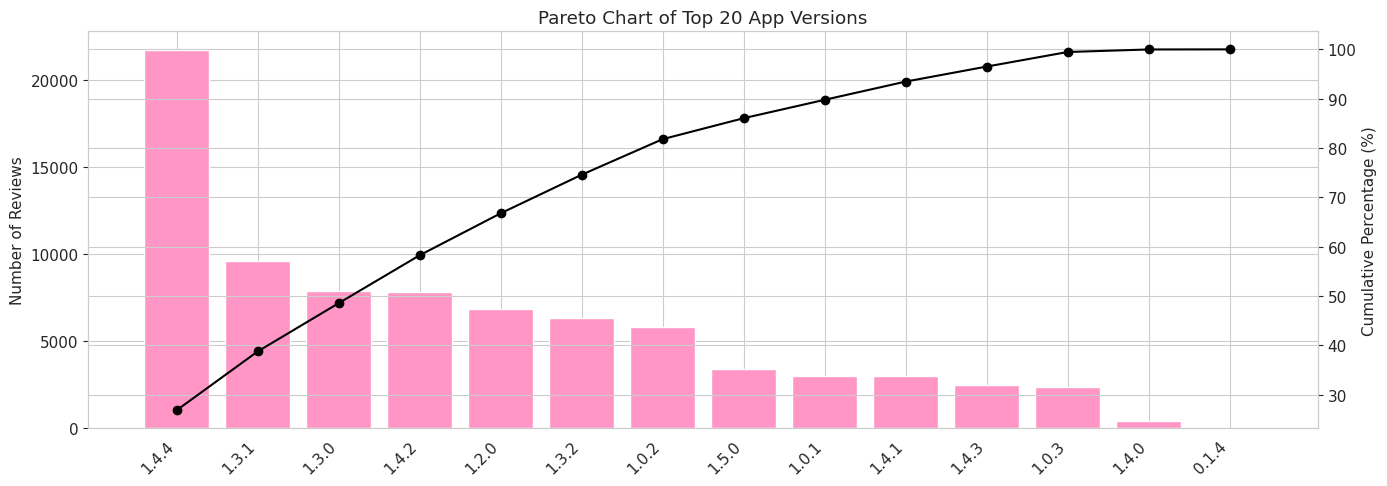

In [39]:
# Reviews per app version (top 20)

version_counts = df['reviewCreatedVersion'].value_counts()

print(f'Total unique app versions: {version_counts.shape[0]}')
print(f'Reviews with missing version: {df["reviewCreatedVersion"].isna().sum():,}')

# Get top 20 versions
top_versions = version_counts.head(20)

# Plot
import numpy as np

fig, ax1 = plt.subplots(figsize=(14, 5))

# Bar chart
ax1.bar(top_versions.index, top_versions.values, color='#FF96C5')
ax1.set_xticklabels(top_versions.index, rotation=45, ha='right')
ax1.set_ylabel('Number of Reviews')

# Cumulative line
cumulative = top_versions.cumsum() / top_versions.sum() * 100

ax2 = ax1.twinx()
ax2.plot(top_versions.index, cumulative, color='black', marker='o')
ax2.set_ylabel('Cumulative Percentage (%)')

plt.title('Pareto Chart of Top 20 App Versions')
plt.tight_layout()
plt.show()

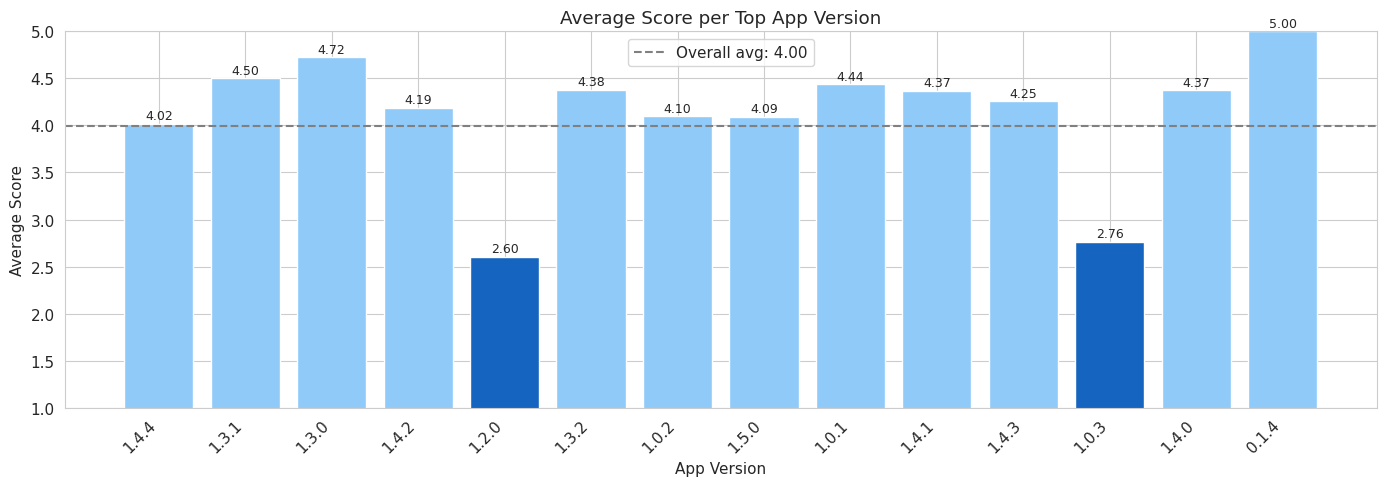

In [40]:
# Average score per top app version

top_ver_list = top_versions.index.tolist()

# Calculate mean score per version
ver_scores = df[df['reviewCreatedVersion'].isin(top_ver_list)] \
    .groupby('reviewCreatedVersion')['score'] \
    .agg(['mean', 'count'])

# Keep original order
ver_scores = ver_scores.loc[top_ver_list]

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

# Color mapping (good / neutral / bad)
bar_colors = []
for s in ver_scores['mean']:
    if s >= 3.5:
        bar_colors.append('#90CAF9')  # light blue (good)
    elif s >= 2.5:
        bar_colors.append('#1565C0')  # dark blue (neutral)
    else:
        bar_colors.append('#FBC02D')  # yellow (bad)

# Bar chart
ax.bar(range(len(ver_scores)), ver_scores['mean'], color=bar_colors)

# Overall average line
overall_avg = df['score'].mean()
ax.axhline(
    y=overall_avg,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label=f'Overall avg: {overall_avg:.2f}'
)

# Labels on top of bars
for i, v in enumerate(ver_scores['mean']):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

# Axis settings
ax.set_xticks(range(len(ver_scores)))
ax.set_xticklabels(ver_scores.index, rotation=45, ha='right')

ax.set_xlabel('App Version')
ax.set_ylabel('Average Score')
ax.set_ylim(1, 5)

ax.set_title('Average Score per Top App Version')
ax.legend()

plt.tight_layout()
plt.show()